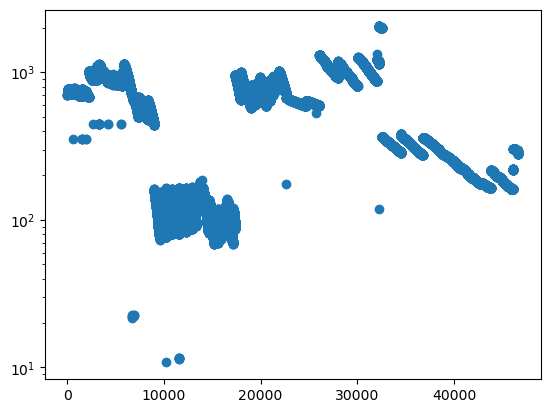

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data = pd.read_csv("./feeds.csv")

def pickfield(data, field_nr):
    field = data[data[field_nr]>10]
    #field.head()
    
    return field

def plotfield(field_nr):
    field = pickfield(data, field_nr)
    
    ax = plt.gca()
    ax.scatter(x=field["entry_id"], y=field[field_nr])
    ax.set_yscale('log')
plotfield("field6")
# plt.show()

In [3]:
import seaborn as sns
import statsmodels.api as sm  
from statsmodels.formula.api import ols 

def select_range(data, field_nr, start, end):
    field = pickfield(data, field_nr)
    #print(field.head())
    field = field[field["entry_id"] > start]
    field = field[field["entry_id"] < end]
    return field
# field8smol['field8'] = field8smol['field8'].shift(-24) - field8smol['field8']
# field8smol = field8smol[field8smol["entry_id"] % 24 == 0]

# sns.residplot(x='entry_id', y='field8', data=field8smol)
# plt.xlabel("entry id")
# plt.ylabel("Residuals")
# plt.show()

#select_range("field7", 43795,45795)
def residual_graph(field_nr, start, end):

    data_field = select_range(data, field_nr, start, end)
    
    lm = ols(f'{field_nr} ~ entry_id', data=data_field).fit()
    print(lm.summary()) 
    fig = plt.figure(figsize=(14, 8))
    fig = sm.graphics.plot_regress_exog(lm, 'entry_id', fig=fig)  

#residual_graph("field7", 43795 ,45795)
#residual_graph("field7", 43795 ,44795)
# ax1 = plt.gca()
# ax1.scatter(x=field8smol["entry_id"], y=field8smol["field8"])

# plt.show()

In [26]:
#!pip install piecewise-regression
import piecewise_regression
pw_fit = piecewise_regression.Fit(list(field8smol["entry_id"]), list(field8smol["field7"]), n_breakpoints=1)
pw_fit.summary()

pw_fit.plot_data(color="grey", s=20)
# Pass in standard matplotlib keywords to control any of the plots
pw_fit.plot_fit(color="red", linewidth=4)
pw_fit.plot_breakpoints()
pw_fit.plot_breakpoint_confidence_intervals()
plt.xlabel("x")
plt.ylabel("y")
plt.show()
plt.close()

NameError: name 'field8smol' is not defined

Cycle lengths: [1483 1931 1994 1964 2221 1703 2800 1980 2017 3052 2000]


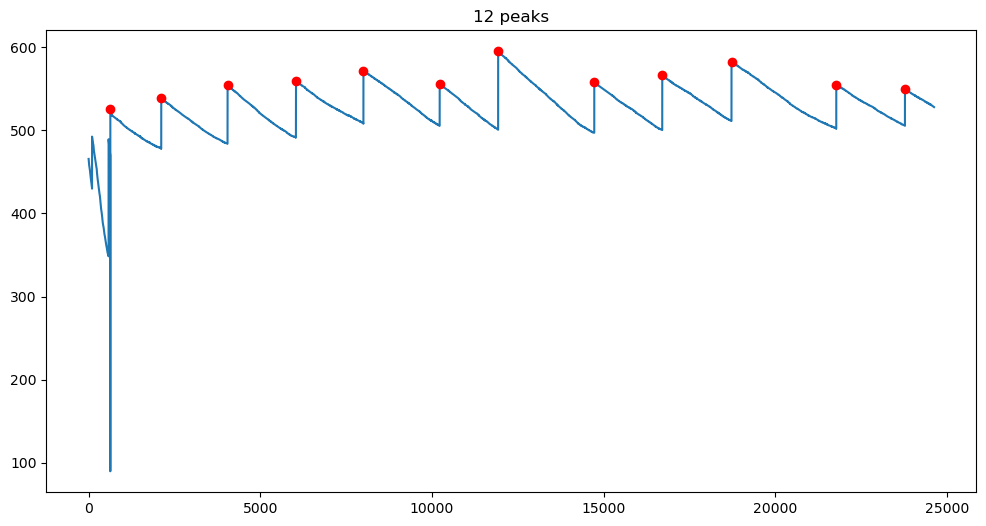

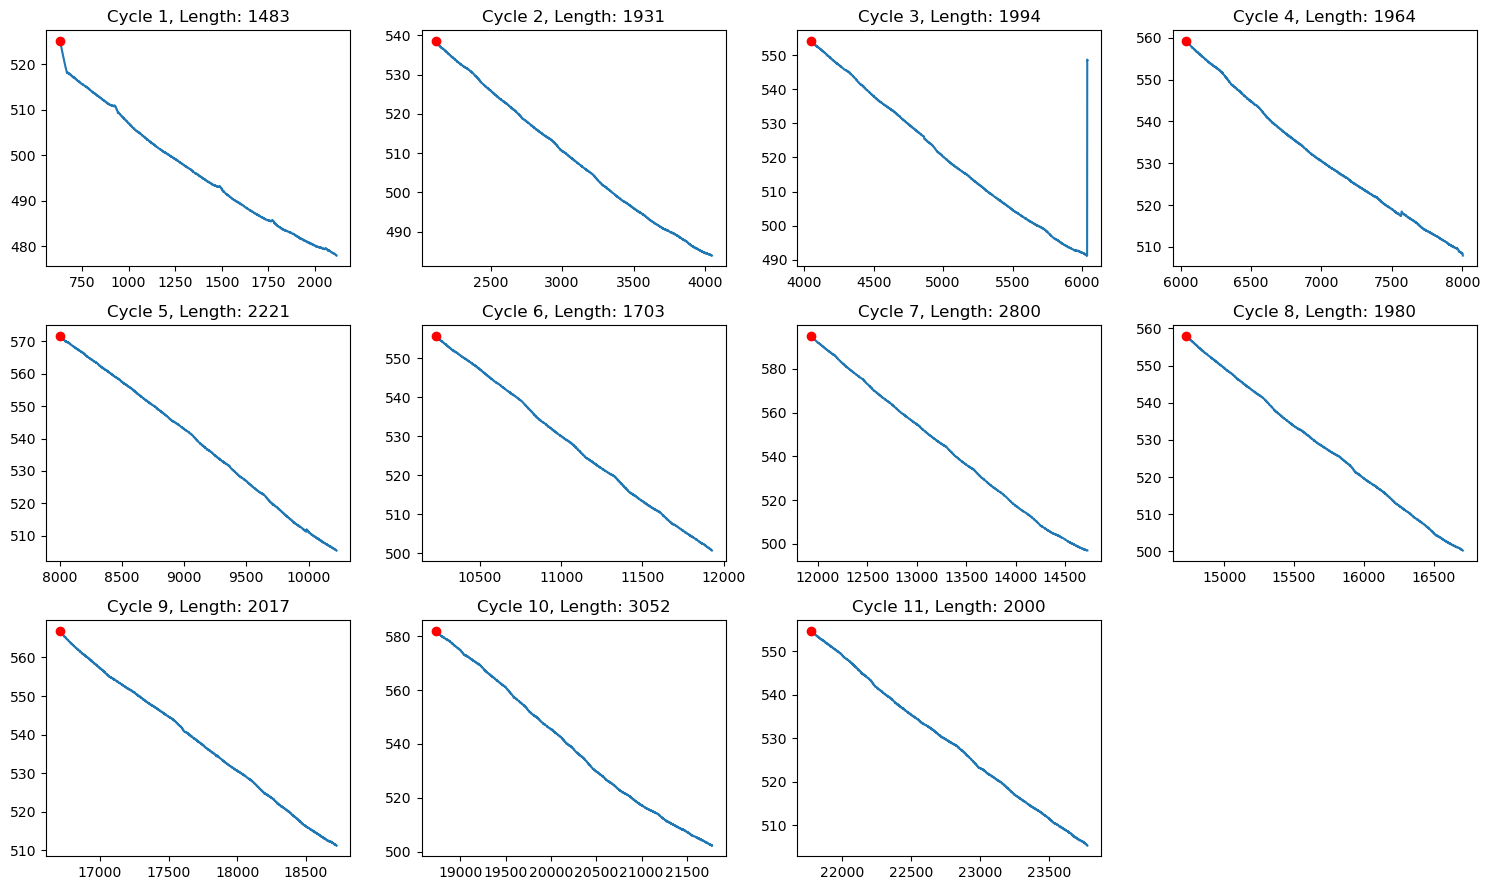

In [2]:
from scipy.signal import find_peaks

y = field7[field7["entry_id"] >22000]["field7"]
y = y.reset_index(drop=True)
x = np.arange(len(y))
#x = field7[field7["entry_id"] >22000]["entry_id"]


peaks, _ = find_peaks(y, distance=1000, prominence=0.5)   # distance prevents false peaks, so does prominence


cycle_lengths = np.diff(peaks)

print("Cycle lengths:", cycle_lengths)
plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.plot(x[peaks], y[peaks], "ro")
plt.title(f"{len(peaks)} peaks")

cycles = len(peaks)-1

if cycles>0:
    n_cols = 4
    n_rows = int(np.ceil(cycles/n_cols))

    plt.figure(figsize=(15,3*n_rows))
    for i in range(cycles):
        start = peaks[i]
        end = peaks[i+1]
        plt.subplot(n_rows, n_cols, i+1)
        plt.plot(x[start:end], y[start:end])
        plt.plot(x[start], y[start], "ro")
        plt.title(f"Cycle {i+1}, Length: {cycle_lengths[i]}")
        
        plt.tight_layout()
plt.show()

<Axes: xlabel='entry_id', ylabel='field7'>

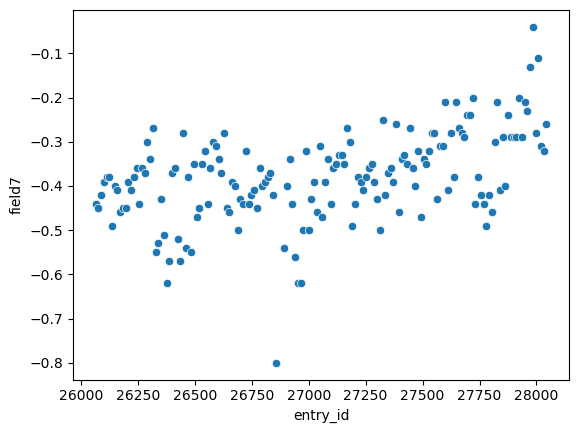

In [68]:

field = select_range(data, "field7", 26059, 28057)
field['field7'] = (field['field7'].shift(-12) - field['field7'])
field = field[field["entry_id"] % 12 == 0]

sns.scatterplot(x='entry_id', y='field7', data=field)

<Axes: xlabel='entry_id', ylabel='field6'>

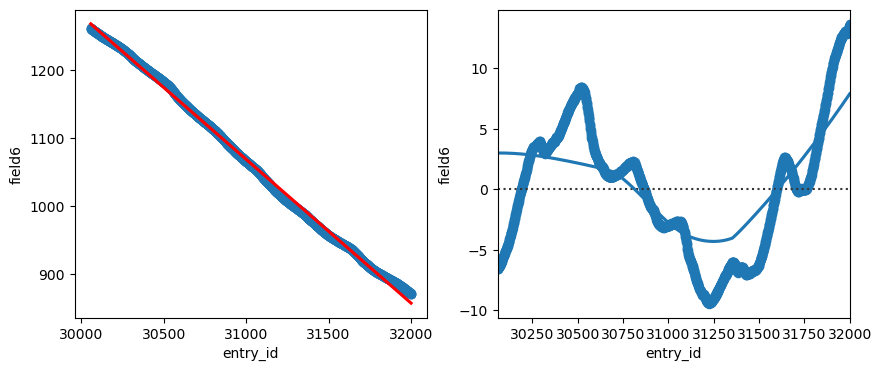

In [122]:
field = select_range(data, "field6", 30057, 32001)
field = field[field["entry_id"] % 1 == 0]
# field['field8'] = (field['field8'].shift(-24) - field['field8'])
# field = field[field["entry_id"] % 24 == 0]
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.regplot(x='entry_id', y='field6', data=field, order = 1, line_kws=dict(color="r"), ax=axs[0])
sns.residplot(x='entry_id', y='field6', data=field, ax=axs[1], lowess = True)
# sns.residplot(x='entry_id', y='field8', data=field8smol)
# plt.xlabel("entry id")
# plt.ylabel("Residuals")
# plt.show()

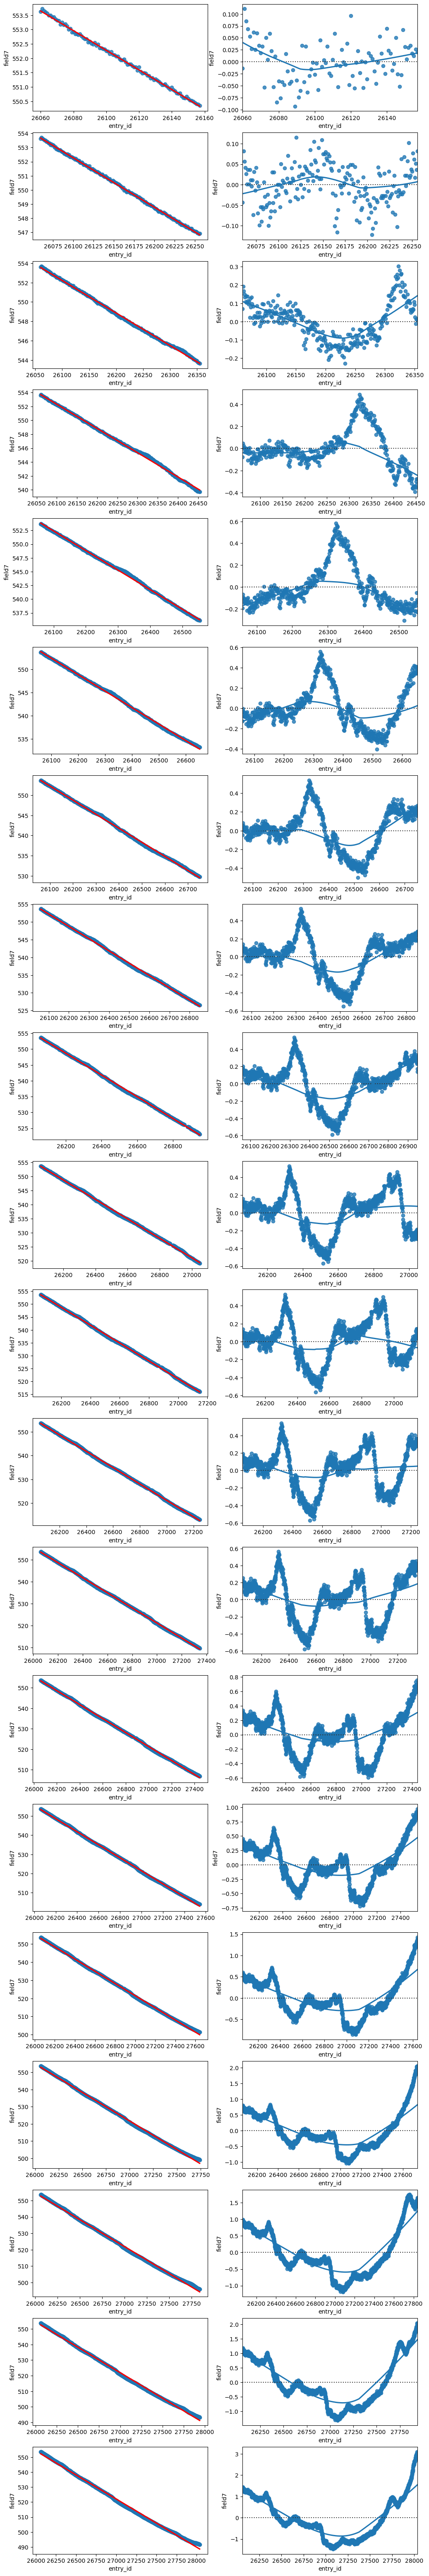

In [69]:
lower = 26059
upper = 28057
diff = upper-lower
chunks = 20

fig, axs = plt.subplots(chunks, 2, figsize=(12, chunks*4))
for i in range(chunks):
    chunkdiff = diff//chunks
    currentlower = lower + i*chunkdiff
    currentupper = lower + (i+1)*chunkdiff 
    field = select_range(data, "field7",lower, currentupper)


    sns.regplot(x='entry_id', y='field7', data=field, order = 1, line_kws=dict(color="r"), ax=axs[i,0], ci = None)
    sns.residplot(x='entry_id', y='field7', data=field, order = 1, ax=axs[i, 1], lowess = True)

In [18]:
data_30 = data.iloc[:22673]
data_5 = data.iloc[22673:]

data_30.to_csv("feeds_30.csv", index=False)
data_5.to_csv("feeds_5.csv", index=False)


In [28]:

from astral.sun import sun
from astral import LocationInfo

data_5 = pd.read_csv("feeds_5.csv")

def add_day_night_column(df, timestamp_col, location):
    
    
    # 1. Ensure the timestamp column is in the correct datetime format
    #    This converts your string into a timezone-aware datetime object.
    #    The `+02:00` offset will be handled automatically.
    df['timestamp'] = pd.to_datetime(df[timestamp_col], utc=True).dt.tz_convert(location.timezone)
    
    # 2. Get the unique dates from your data
    df['date'] = df['timestamp'].dt.date
    unique_dates = df['date'].unique()
    
    # 3. Create a lookup map for sunrise/sunset times (the "algorithm")
    #    This is the core optimization: we only calculate once per day.
    sun_times_map = {}
    for date in unique_dates:
        s = sun(location.observer, date=date)
        sun_times_map[date] = {'sunrise': s['sunrise'], 'sunset': s['sunset']}
        
    # 4. Map these times back to your original DataFrame
    df['sunrise'] = df['date'].map(lambda x: sun_times_map[x]['sunrise'])
    df['sunset'] = df['date'].map(lambda x: sun_times_map[x]['sunset'])
    
    # 5. Perform the vectorized comparison
    df['ToD'] = np.where(
        (df['timestamp'] >= df['sunrise']) & (df['timestamp'] < df['sunset']),
        'Day',
        'Night'
    )
    
    # 6. Clean up temporary columns
    df = df.drop(columns=['date', 'sunrise', 'sunset'])
    
    return df

# --- How to Use It ---

# 1. Define your location (Tartu, Estonia)
# You can find coordinates for other cities easily.
loc = LocationInfo(name="Tartu", region="Estonia", timezone="Europe/Tallinn",
                   latitude=58.3780, longitude=26.7290)


data_5 = add_day_night_column(data_5, timestamp_col='created_at', location=loc)

print(data_5["ToD"].value_counts())

ToD
Day      16002
Night     7972
Name: count, dtype: int64


<Axes: xlabel='entry_id', ylabel='field8'>

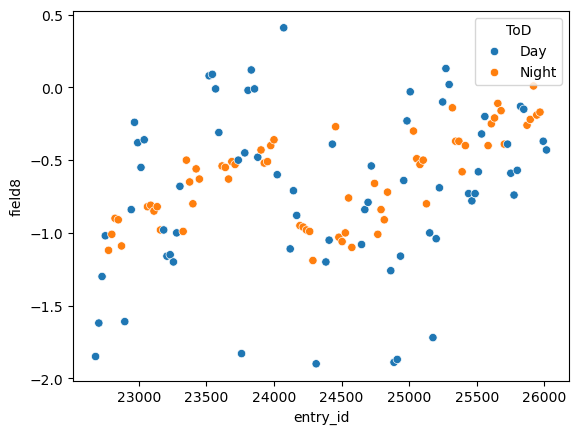

In [51]:


field = select_range(data_5, "field8", 22674, 26050)
field['field8'] = (field['field8'].shift(-24) - field['field8'])
field = field[field["entry_id"] % 24 == 0]
field = field[field["field8"] > -2]
field = field[field["field8"] < 3]


sns.scatterplot(x='entry_id', y='field8', hue="ToD", data=field)

27433 SIIN
66.29349815206325 222 27441


<Axes: xlabel='entry_id', ylabel='Residuals'>

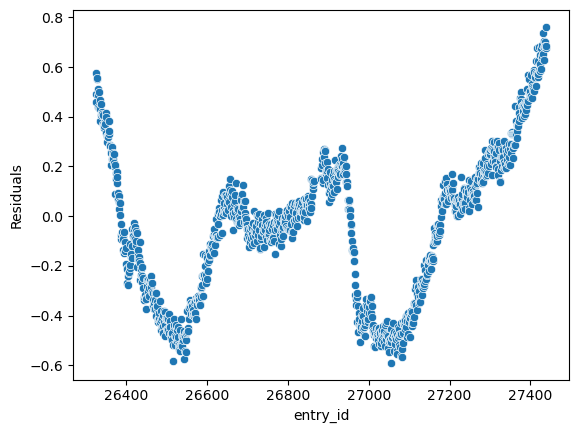

In [51]:
import statsmodels.api as sm
data_5 = pd.read_csv("feeds_5.csv")

def model_avg_residual(data, lower_bound, upper_bound):
    broken = False
    lower = lower_bound
    upperlimit = lower + 288
    upper = upper_bound
    
    field = select_range(data, "field7", lower, upper)
    
    for i in range(upper-upperlimit):
        #print(upperlimit)
        current_field = field[field["entry_id"] < upperlimit].copy()
        #current_field = current_field[current_field["entry_id"]%1 == 0]
        x = current_field["entry_id"]
        y = current_field["field7"]
      
        
        x = sm.add_constant(x)
        model = sm.OLS(y, x)
        results = model.fit()
    
        current_field["Residuals"] = results.resid
        #print(int(current_field["entry_id"].iloc[0]), )
        
       
        #print(half_max)
    
        poolindeks = len(current_field.index)//2
        #print(poolindeks)
        half_max = current_field[current_field["entry_id"]<(int(current_field["entry_id"].iloc[0])+poolindeks)]["Residuals"].max()
        
            
        half_max_index = current_field[current_field["Residuals"] == half_max]["entry_id"].iloc[0].item()
    
        half_max *= 0.5
        current_field = current_field[current_field["entry_id"] > half_max_index]
        poolindeks = len(current_field.index)//2
        # x = current_field["entry_id"]
        # y = current_field["field6"]
      
        
        # x = sm.add_constant(x)
        # model = sm.OLS(y, x)
        # results = model.fit()
    
        # current_field["Residuals"] = results.resid
    
        x = 0
        residsum = 0
        count = 0
        
        
        for resid in current_field[current_field["entry_id"]>(int(current_field["entry_id"].iloc[0])+poolindeks)]["Residuals"]:
            
            #highest = 
            
            if resid >= 0:
                residsum += resid
                count += 1
                
                #and count >= 288
                if residsum/count >= half_max and count >= 144 and (upperlimit - (x + int(current_field["entry_id"].iloc[0])+poolindeks)) <= 10:
                    broken = True
                    print(x + int(current_field["entry_id"].iloc[0])+poolindeks, "SIIN")
                    break
            else:
                residsum = 0
                count = 0
            x += 1
        if broken:
            break
        upperlimit += 1
    
model_avg_residual(data_5, 26059, 28057)
print(residsum, count, upperlimit)
sns.scatterplot(data = current_field, x="entry_id", y="Residuals")

In [ ]:
def cumSum_threshold(weight, interval):
    
    